<a href="https://colab.research.google.com/github/www-fidezDAE/fidez.RDS/blob/main/Rita_MSTAT_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pymc

In [ ]:
pip install pymc==5.9.0 arviz==0.15.1 scipy==1.10.1

  Using cached pymc-5.9.0-py3-none-any.whl.metadata (10 kB)
  Using cached arviz-0.15.1-py3-none-any.whl.metadata (8.5 kB)
ERROR: Ignored the following yanked versions: 1.11.0, 1.14.0rc1
ERROR: Ignored the following versions that require a different python version: 1.10.0 Requires-Python <3.12,>=3.8; 1.10.0rc1 Requires-Python <3.12,>=3.8; 1.10.0rc2 Requires-Python <3.12,>=3.8; 1.10.1 Requires-Python <3.12,>=3.8; 1.6.2 Requires-Python >=3.7,<3.10; 1.6.3 Requires-Python >=3.7,<3.10; 1.7.0 Requires-Python >=3.7,<3.10; 1.7.1 Requires-Python >=3.7,<3.10; 1.7.2 Requires-Python >=3.7,<3.11; 1.7.3 Requires-Python >=3.7,<3.11; 1.8.0 Requires-Python >=3.8,<3.11; 1.8.0rc1 Requires-Python >=3.8,<3.11; 1.8.0rc2 Requires-Python >=3.8,<3.11; 1.8.0rc3 Requires-Python >=3.8,<3.11; 1.8.0rc4 Requires-Python >=3.8,<3.11; 1.8.1 Requires-Python >=3.8,<3.11; 1.9.0 Requires-Python >=3.8,<3.12; 1.9.0rc1 Requires-Python >=3.8,<3.12; 1.9.0rc2 Requires-Python >=3.8,<3.12; 1.9.0rc3 Requires-Python >=3.8,<3.12; 1.9

Dataset loaded. Rows: 14
Columns: ['Child_ID', 'Household_ID', 'Region', 'Age_Months', 'Sex', 'Nutrition_Status', 'Stunted', 'Overweight', 'Underweight', 'Maternal_Education', 'Wealth_Quintile', 'VitaminA_24h', 'Iron_24h', 'Iodized_Salt', 'Immunization_Status', 'Birth_Order']


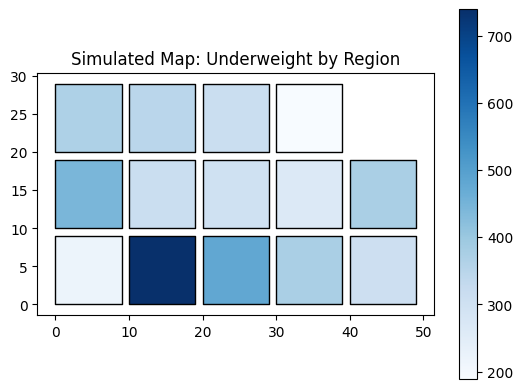

('WARNING: ', 0, ' is an island (no neighbors)')
('WARNING: ', 1, ' is an island (no neighbors)')
('WARNING: ', 2, ' is an island (no neighbors)')
('WARNING: ', 3, ' is an island (no neighbors)')
('WARNING: ', 4, ' is an island (no neighbors)')
('WARNING: ', 5, ' is an island (no neighbors)')
('WARNING: ', 6, ' is an island (no neighbors)')
('WARNING: ', 7, ' is an island (no neighbors)')
('WARNING: ', 8, ' is an island (no neighbors)')
('WARNING: ', 9, ' is an island (no neighbors)')
('WARNING: ', 10, ' is an island (no neighbors)')
('WARNING: ', 11, ' is an island (no neighbors)')
('WARNING: ', 12, ' is an island (no neighbors)')
('WARNING: ', 13, ' is an island (no neighbors)')

Moran’s I for Underweight: nan p-value: 0.001
Design matrix rank: 6 / 6 columns
LinAlgError during Logit fit: Singular matrix
Falling back to scikit-learn LogisticRegression with L2 penalty.
Scikit-learn LogisticRegression fit succeeded.

Markov Transition Matrix:
Nutrition_Status    Normal  Overweight   Stu

Output()


Bayesian Model Summary:
           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha    -0.407  1.199  -2.725    1.831      0.042    0.036     828.0   
beta_age -0.393  0.373  -1.083    0.338      0.013    0.011     906.0   
beta_sex -0.351  0.839  -1.961    1.090      0.026    0.022    1014.0   

          ess_tail  r_hat  
alpha        786.0    1.0  
beta_age     899.0    1.0  
beta_sex     960.0    1.0  

Predictive Evaluation:
AUC: 0.667, Brier: 0.143, MAE: 0.143, RMSE: 0.378


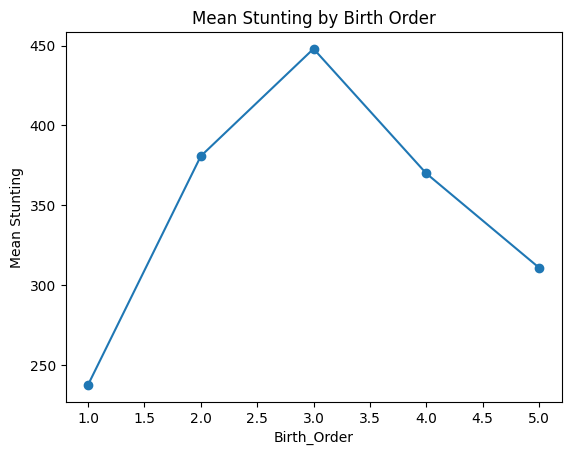

In [ ]:
# Combined pipeline (robust logistic regression and safe fallbacks)
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Polygon
from esda.moran import Moran
from libpysal.weights import Queen
from statsmodels.discrete.discrete_model import Logit
from statsmodels.tools import add_constant
import statsmodels.api as sm
import pymc as pm
import arviz as az
from sklearn.metrics import roc_auc_score, brier_score_loss, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LogisticRegression
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# -------------------------
# Data preprocessing helpers (unchanged)
# -------------------------
def load_data(EXCEL_PATH):
    df = pd.read_excel(EXCEL_PATH)
    print("Dataset loaded. Rows:", len(df))
    print("Columns:", df.columns.tolist())
    return df

def preprocess_data(df):
    df = df.copy()
    df.columns = df.columns.str.strip().str.replace(" ", "_")

    # Numeric columns
    numeric_cols = ["Normal", "Stunted", "Overweight", "Underweight",
                    "VitaminA_24h", "Iron_24h", "Iodized_Salt"]
    for c in numeric_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')

    # Encode categoricals
    cat_cols = ["Age_Months", "Sex", "Nutrition_Status",
                "Maternal_Education", "Wealth_Quintile",
                "Immunization_Status", "Region"]
    encoders = {}
    for c in cat_cols:
        if c in df.columns:
            df[c] = df[c].astype(str).str.strip()
            le = LabelEncoder()
            df[c + "_enc"] = le.fit_transform(df[c])
            encoders[c] = le
    return df, encoders

# -------------------------
# Spatial analysis helpers (unchanged)
# -------------------------
def simulate_district_shapefile(regions):
    polygons = []
    for i, region in enumerate(regions):
        x0, y0 = (i % 5) * 10, (i // 5) * 10  # grid layout
        poly = Polygon([(x0, y0), (x0+9, y0), (x0+9, y0+9), (x0, y0+9)])
        polygons.append(poly)
    gdf = gpd.GeoDataFrame({"Region": regions, "geometry": polygons}, crs="EPSG:4326")
    return gdf

def run_spatial_analysis(df):
    regions = df["Region"].unique().tolist()
    gdf_sim = simulate_district_shapefile(regions)
    gdf_merged = gdf_sim.merge(df.groupby("Region", as_index=False).mean(numeric_only=True), on="Region")
    gdf_merged.plot(column="Underweight", cmap="Blues", legend=True, edgecolor="black")
    plt.title("Simulated Map: Underweight by Region")
    plt.show()
    w = Queen.from_dataframe(gdf_merged)
    mi = Moran(gdf_merged["Underweight"].fillna(0), w)
    print("\nMoran’s I for Underweight:", mi.I, "p-value:", mi.p_sim)
    return gdf_merged, mi

# -------------------------
# Robust logistic regression
# -------------------------
def run_logistic_regression(df, verbose=True):
    # Select candidate predictors
    candidate_cols = ["Age_Months_enc", "Sex_enc", "Maternal_Education_enc",
                      "Wealth_Quintile_enc", "Immunization_Status_enc"]
    present = [c for c in candidate_cols if c in df.columns]
    if len(present) == 0:
        raise ValueError("No predictor columns found in df for logistic regression.")

    X = df[present].copy()
    y = (df["Nutrition_Status"] == "Stunted").astype(int)

    # Drop rows where y is NaN or where all X are NaN
    valid_idx = (~y.isna()) & (~X.isna().all(axis=1))
    X = X.loc[valid_idx].copy()
    y = y.loc[valid_idx].copy()

    # Ensure numeric dtype
    X = X.apply(pd.to_numeric, errors='coerce').astype(float)

    # 1) Drop zero-variance columns
    zero_var_cols = [col for col in X.columns if X[col].nunique(dropna=True) <= 1]
    if zero_var_cols:
        if verbose:
            print("Dropping zero-variance columns:", zero_var_cols)
        X = X.drop(columns=zero_var_cols)

    # 2) Drop duplicated columns (exact duplicates)
    dup_cols = []
    cols = X.columns.tolist()
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            if X[cols[i]].equals(X[cols[j]]):
                dup_cols.append(cols[j])
    dup_cols = list(set(dup_cols))
    if dup_cols:
        if verbose:
            print("Dropping duplicated columns:", dup_cols)
        X = X.drop(columns=dup_cols)

    # 3) Add constant
    X_const = add_constant(X, has_constant='add')

    # 4) Check matrix rank
    mat = X_const.fillna(0).values.astype(float)
    rank = np.linalg.matrix_rank(mat)
    ncols = mat.shape[1]
    if verbose:
        print(f"Design matrix rank: {rank} / {ncols} columns")

    # 5) Try standard Logit if full rank, otherwise try regularized, otherwise sklearn fallback
    try:
        if rank == ncols:
            model = Logit(y.values, X_const).fit(disp=0)
            if verbose:
                print("\nLogit fit succeeded (MLE).")
            return model, X_const, y
        else:
            # Use statsmodels regularized fit
            if verbose:
                print("Matrix is rank-deficient. Trying regularized Logit (fit_regularized).")
            model = Logit(y.values, X_const).fit_regularized(method='l1', disp=0)
            if verbose:
                print("\nRegularized Logit fit succeeded (fit_regularized).")
            return model, X_const, y
    except np.linalg.LinAlgError as e:
        if verbose:
            print("LinAlgError during Logit fit:", e)
            print("Falling back to scikit-learn LogisticRegression with L2 penalty.")
        # sklearn fallback
        clf = LogisticRegression(max_iter=2000, solver='liblinear')  # liblinear handles small datasets well
        clf.fit(X_const.fillna(0).values, y.values)
        if verbose:
            print("Scikit-learn LogisticRegression fit succeeded.")
        return clf, X_const, y

# -------------------------
# Markov chain (unchanged)
# -------------------------
def run_markov_chain(df):
    transitions = pd.crosstab(df["Nutrition_Status"],
                              df["Nutrition_Status"].shift(-1),
                              normalize="index")
    print("\nMarkov Transition Matrix:")
    print(transitions)
    return transitions

# -------------------------
# Bayesian model (unchanged)
# -------------------------
def run_bayesian_model(df, y):
    with pm.Model() as model:
        alpha = pm.Normal("alpha", mu=0, sigma=10)
        beta_age = pm.Normal("beta_age", mu=0, sigma=1)
        beta_sex = pm.Normal("beta_sex", mu=0, sigma=1)

        logit_p = alpha + beta_age * df["Age_Months_enc"].values + beta_sex * df["Sex_enc"].values
        p = pm.math.sigmoid(logit_p)

        y_obs = pm.Bernoulli("y_obs", p=p, observed=y.values)

        trace = pm.sample(1000, tune=500, cores=1, target_accept=0.9)

    print("\nBayesian Model Summary:")
    print(az.summary(trace, var_names=["alpha", "beta_age", "beta_sex"]))

    return trace

# -------------------------
# Evaluation helper (fixed RMSE calculation)
# -------------------------
def evaluate_predictions(model, X_const, y):
    # model may be statsmodels Logit, statsmodels RegularizedResults, or sklearn LogisticRegression
    if hasattr(model, "predict"):
        # statsmodels: model.predict accepts dataframe
        try:
            y_pred_prob = model.predict(X_const)
        except Exception:
            # sklearn fallback
            y_pred_prob = model.predict_proba(X_const.fillna(0).values)[:, 1]
    else:
        y_pred_prob = model.predict_proba(X_const.fillna(0).values)[:, 1]

    auc = roc_auc_score(y, y_pred_prob) if len(np.unique(y)) > 1 else float('nan')
    brier = brier_score_loss(y, y_pred_prob)
    mae = mean_absolute_error(y, y_pred_prob)
    # compute MSE normally and take sqrt for RMSE to avoid 'squared' kw issues
    mse = mean_squared_error(y, y_pred_prob)
    rmse = np.sqrt(mse)

    print("\nPredictive Evaluation:")
    print(f"AUC: {auc:.3f}, Brier: {brier:.3f}, MAE: {mae:.3f}, RMSE: {rmse:.3f}")
    return auc, brier, mae, rmse

# -------------------------
# Visualization helper (unchanged)
# -------------------------
def plot_temporal(df):
    if "Birth_Order" in df.columns:
        df.groupby("Birth_Order")["Stunted"].mean().plot(marker="o")
        plt.title("Mean Stunting by Birth Order")
        plt.ylabel("Mean Stunting")
        plt.show()

# -------------------------
# Main execution (example)
# -------------------------
EXCEL_PATH = "Malnutrition_Dataset.xlsx"  # update path if needed
df = load_data(EXCEL_PATH)
df_clean, encoders = preprocess_data(df)

# Spatial
gdf_merged, mi = run_spatial_analysis(df_clean)

# Robust logistic regression
logit_model, X_const, y = run_logistic_regression(df_clean)

# Markov chain
transitions = run_markov_chain(df_clean)

# Bayesian model (will use same y and df; ensure alignment)
trace = run_bayesian_model(df_clean, y)

# Evaluation
auc, brier, mae, rmse = evaluate_predictions(logit_model, X_const, y)

# Visualization
plot_temporal(df_clean)


Sheets loaded successfully:
Bayesian_Data: (14, 16)
Markov_Transitions: (14, 3)
Transition_Counts: (14, 3)
Spatial_Temporal: (14, 7)
Model_Outputs: (14, 4)

Logistic Regression for Stunted_Flag
                           Logit Regression Results                           
Dep. Variable:           Stunted_Flag   No. Observations:                   14
Model:                          Logit   Df Residuals:                        9
Method:                           MLE   Df Model:                            4
Date:                Wed, 10 Sep 2025   Pseudo R-squ.:                   1.000
Time:                        18:10:33   Log-Likelihood:            -2.9117e-08
converged:                      False   LL-Null:                       -7.2741
Covariance Type:            nonrobust   LLR p-value:                  0.005736
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -54

Output()

           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha    -0.373  1.185  -2.521    1.837      0.038    0.030     961.0   
beta_sex -0.342  0.813  -1.806    1.174      0.024    0.019    1157.0   
beta_age -0.403  0.377  -1.146    0.273      0.011    0.010    1084.0   

          ess_tail  r_hat  
alpha       1077.0    1.0  
beta_sex    1047.0    1.0  
beta_age    1045.0    1.0  


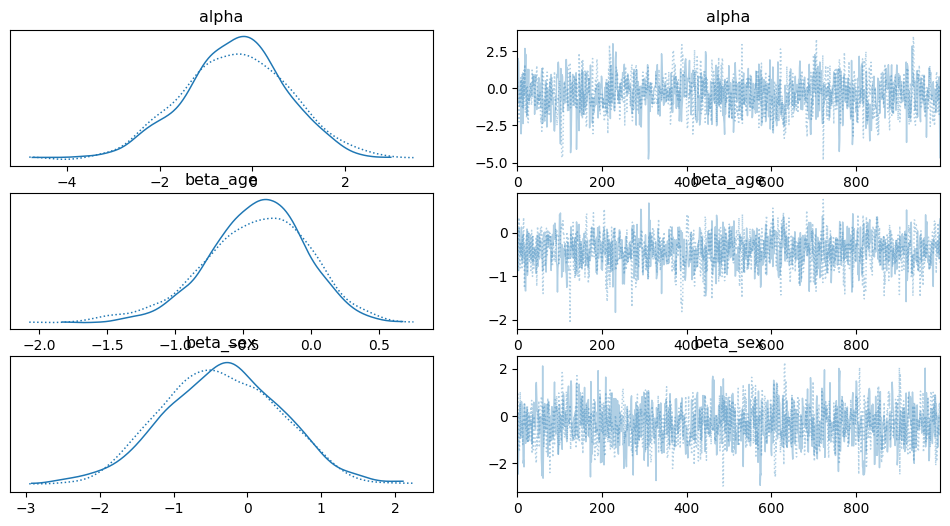

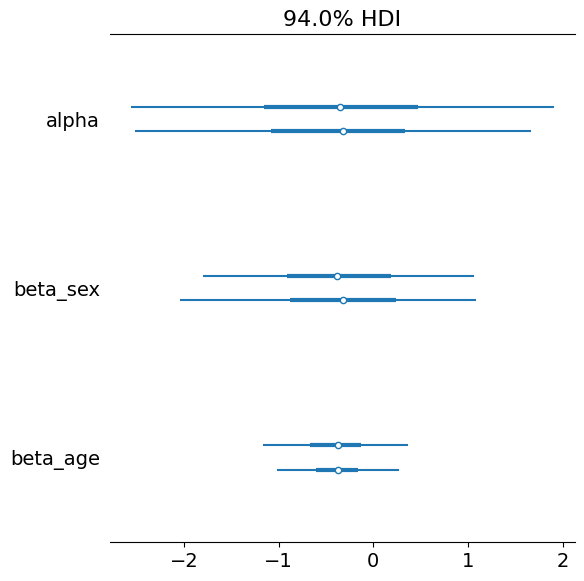

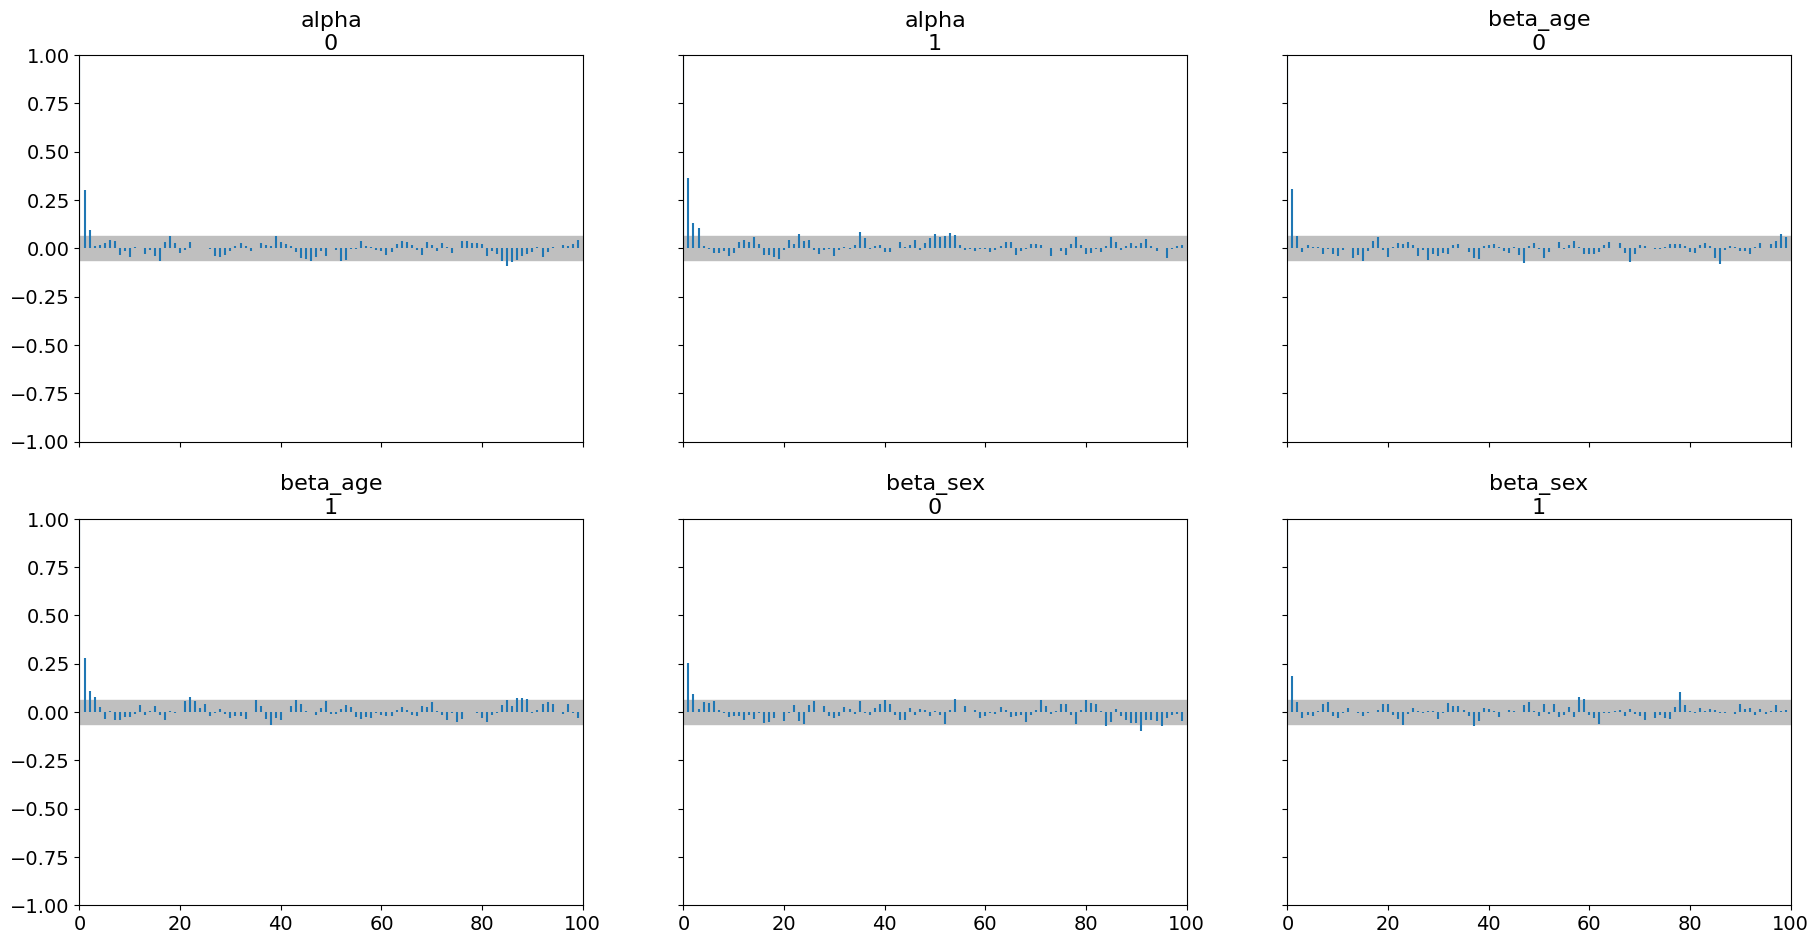

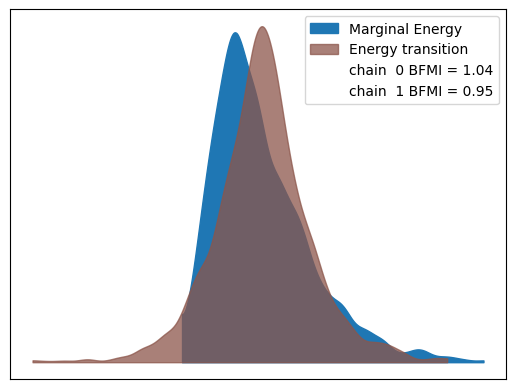

Output()

AttributeError: module 'arviz' has no attribute 'from_pymc'

In [ ]:
# ===============================
# Install dependencies (Colab only)
# ===============================
!pip install pymc arviz geopandas libpysal esda shapely openpyxl

# ===============================
# Import libraries
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Polygon

# Stats & ML
from statsmodels.discrete.discrete_model import Logit
from statsmodels.tools import add_constant
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss, mean_absolute_error, mean_squared_error

# Bayesian
import pymc as pm
import arviz as az

# Spatial analysis
from esda.moran import Moran
from libpysal.weights import Queen

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# ===============================
# Load Excel with multiple sheets
# ===============================
EXCEL_PATH = "/content/Malnutrition_Dataset.xlsx"  # upload to Colab

data_bayes = pd.read_excel(EXCEL_PATH, sheet_name="Bayesian_Data")
data_markov = pd.read_excel(EXCEL_PATH, sheet_name="Markov_Transitions")
data_counts = pd.read_excel(EXCEL_PATH, sheet_name="Transition_Counts")
data_spatial = pd.read_excel(EXCEL_PATH, sheet_name="Spatial_Temporal")
data_outputs = pd.read_excel(EXCEL_PATH, sheet_name="Model_Outputs")

print("Sheets loaded successfully:")
print("Bayesian_Data:", data_bayes.shape)
print("Markov_Transitions:", data_markov.shape)
print("Transition_Counts:", data_counts.shape)
print("Spatial_Temporal:", data_spatial.shape)
print("Model_Outputs:", data_outputs.shape)


# ===================================================
# Objective i: Logistic Regression (Risk Factor Models)
# ===================================================
def run_logistic_regression(df, outcome_col):
    df = df.copy()
    df[outcome_col] = (df["Nutrition_Status"] == outcome_col.split("_")[0]).astype(int)

    # Encode categoricals
    df["Sex_enc"] = df["Sex"].astype("category").cat.codes
    df["Edu_enc"] = df["Maternal_Education"].astype("category").cat.codes
    df["Wealth_enc"] = df["Wealth_Quintile"].astype("category").cat.codes
    df["Immun_enc"] = df["Immunization_Status"].astype("category").cat.codes

    X = df[["Sex_enc", "Edu_enc", "Wealth_enc", "Immun_enc"]]
    y = df[outcome_col]

    X_const = add_constant(X, has_constant="add")

    try:
        model = Logit(y, X_const).fit(disp=0)
        print(f"\nLogistic Regression for {outcome_col}")
        print(model.summary())
    except Exception:
        print(f"Falling back to sklearn LogisticRegression for {outcome_col}")
        model = LogisticRegression(max_iter=2000).fit(X_const, y)

    return model, X_const, y

# Run for each nutritional status
logit_stunted, X_stunted, y_stunted = run_logistic_regression(data_bayes, "Stunted_Flag")
logit_normal, X_normal, y_normal = run_logistic_regression(data_bayes, "Normal_Flag")
logit_over, X_over, y_over = run_logistic_regression(data_bayes, "Overweight_Flag")
logit_under, X_under, y_under = run_logistic_regression(data_bayes, "Underweight_Flag")


# ===================================================
# Objective ii: Markov Chain (Malnutrition Progression)
# ===================================================
def run_markov_chain(transitions_df):
    matrix = pd.crosstab(
        transitions_df["Nutrition_Status"],
        transitions_df["Nutrition_Status"].shift(-1),
        normalize="index"
    )
    print("\nMarkov Transition Matrix:\n", matrix)
    return matrix

markov_matrix = run_markov_chain(data_markov)


# ===================================================
# Objective iii: Bayesian Model + Validation
# ===================================================
def run_bayesian_model(df):
    df = df.copy()
    y = (df["Nutrition_Status"] == "Stunted").astype(int)
    sex = df["Sex"].astype("category").cat.codes.values
    age = df["Age_Months"].astype("category").cat.codes.values

    with pm.Model() as model:
        alpha = pm.Normal("alpha", mu=0, sigma=10)
        beta_sex = pm.Normal("beta_sex", mu=0, sigma=1)
        beta_age = pm.Normal("beta_age", mu=0, sigma=1)

        logit_p = alpha + beta_sex * sex + beta_age * age
        p = pm.math.sigmoid(logit_p)

        y_obs = pm.Bernoulli("y_obs", p=p, observed=y)

        trace = pm.sample(1000, tune=500, target_accept=0.9)

    # Posterior summaries and parameter plots
    print(az.summary(trace, var_names=["alpha", "beta_sex", "beta_age"]))
    az.plot_trace(trace)
    plt.show()
    az.plot_forest(trace, var_names=["alpha", "beta_sex", "beta_age"])
    plt.show()
    az.plot_autocorr(trace)
    plt.show()
    az.plot_energy(trace)
    plt.show()

    # Posterior predictive check
    with model:
        ppc = pm.sample_posterior_predictive(trace, var_names=["y_obs"])
    az.plot_ppc(az.from_pymc(trace=trace, posterior_predictive=ppc, model=model))
    plt.show()

    return trace

trace = run_bayesian_model(data_bayes)


# ===================================================
# Objective iv: Spatial & Temporal Analysis
# ===================================================
def simulate_district_shapefile(regions):
    polygons = []
    for i, region in enumerate(regions):
        x0, y0 = (i % 5) * 10, (i // 5) * 10
        poly = Polygon([(x0, y0), (x0+9, y0), (x0+9, y0+9), (x0, y0+9)])
        polygons.append(poly)
    gdf = gpd.GeoDataFrame({"Region": regions, "geometry": polygons}, crs="EPSG:4326")
    return gdf

def run_spatial_analysis(df):
    gdf_sim = simulate_district_shapefile(df["Region"].unique())
    gdf_merged = gdf_sim.merge(df, on="Region")

    # Stunted map
    gdf_merged.plot(column="Stunted", cmap="Reds", legend=True, edgecolor="black")
    plt.title("Stunting by Region (Simulated Map)")
    plt.show()

    # Normal map
    gdf_merged.plot(column="Normal", cmap="Blues", legend=True, edgecolor="black")
    plt.title("Normal by Region (Simulated Map)")
    plt.show()

    # Overweight map
    gdf_merged.plot(column="Overweight", cmap="Greens", legend=True, edgecolor="black")
    plt.title("Overweight by Region (Simulated Map)")
    plt.show()

    # Underweight map
    gdf_merged.plot(column="Underweight", cmap="Purples", legend=True, edgecolor="black")
    plt.title("Underweight by Region (Simulated Map)")
    plt.show()

    # Moran’s I for stunting
    w = Queen.from_dataframe(gdf_merged)
    mi = Moran(gdf_merged["Stunted"], w)
    print("\nMoran’s I:", mi.I, " p-value:", mi.p_sim)

    return gdf_merged, mi

gdf_merged, mi = run_spatial_analysis(data_spatial)


# ===================================================
# Objective v: Evaluation & Policy Insights
# ===================================================
def evaluate_predictions(model, X, y, label="Model"):
    try:
        y_pred_prob = model.predict(X)
    except:
        y_pred_prob = model.predict_proba(X)[:, 1]

    auc = roc_auc_score(y, y_pred_prob) if len(np.unique(y)) > 1 else np.nan
    brier = brier_score_loss(y, y_pred_prob)
    mae = mean_absolute_error(y, y_pred_prob)
    mse = mean_squared_error(y, y_pred_prob)
    rmse = np.sqrt(mse)

    print(f"\n{label} Evaluation Metrics:\nAUC={auc:.3f}, Brier={brier:.3f}, MAE={mae:.3f}, MSE={mse:.3f}, RMSE={rmse:.3f}")
    return auc, brier, mae, mse, rmse

evaluate_predictions(logit_stunted, X_stunted, y_stunted, "Stunted Model")
evaluate_predictions(logit_normal, X_normal, y_normal, "Normal Model")
evaluate_predictions(logit_over, X_over, y_over, "Overweight Model")
evaluate_predictions(logit_under, X_under, y_under, "Underweight Model")

print("\nPolicy Recommendations (from Model_Outputs):")
print(data_outputs)
